### Calcuating Boltzmann Constant from Johnson Noise Varying Temperature

In this section of the experiment, we change the temperature of the resistors that generates the Johnson Noise. To achieve this, we submerge a temperature probe into a ---- of liquid nitrogen (LN2).To find the uncertainties in our measurements, we look at the data sheets for our handheld multimeter, which is used to calculate the resistance of our resistor, our multimeter, which is used to calculate Johnson Noise squared, and two thermometers, measuring the temperature of the room.

Here are the datasheets we look at for error propogation:

https://www.dropbox.com/scl/fi/1vq24o1unn4n0ikm1oeed/ZT111-Eng.pdf?rlkey=g51p6y0agtyp7edrfm9i7kx83&e=1&dl=0
https://www.manualslib.com/manual/1522469/Zotek-Zt111.html
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://res.cloudinary.com/iwh/image/upload/q_auto,g_center/assets/1/26/Documents/Protek/protekb8040fd_datasheet.pdf

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd

In [10]:
# Data input
df = pd.read_csv("/Users/jacobbalek/Documents/The Ohio State University/PHYS 5700 Adv Physics Lab/PHYS 5700 Adv Physics Lab Spring 2026/Johnson Noise/Johnson_Noise_T.csv")
print("Length of full df: ", len(df)) #Expect 6 * 15 = 90
print(df.head(), "\n")

# Remove NaN cols (clean)
df_clean = df.dropna()
print("Length of Cleaned df: ", len(df_clean), "\n")

print("Columns in df: ")
for col in df_clean:
    print(col)

Length of full df:  174
  Temperature (mV)  G2 Gain  <Vsq> read (mV)  Mean <Vsq> Read (mV)  \
0            976.8   5000.0             9817           9809.666667   
1              NaN      NaN             9791                   NaN   
2              NaN      NaN             9774                   NaN   
3              NaN      NaN             9831                   NaN   
4              NaN      NaN             9823                   NaN   

   STD <Vsq> Read (mV)       Bandwidth (Delta f) Resistor Measurement (Ohms)  
0            22.178067  9997 (f1 = 1k, f2 = 10k)            (Rb, Remote 10k)  
1                  NaN                       NaN                         NaN  
2                  NaN                       NaN                         NaN  
3                  NaN                       NaN                         NaN  
4                  NaN                       NaN                         NaN   

Length of Cleaned df:  29 

Columns in df: 
Temperature (mV)
G2 Gain
<Vsq> read

In [11]:
# Plot values from "Mean <Vsq> Read (V)"
voltage = df_clean["<Vsq> read (mV)"]
gain = df_clean["G2 Gain"]
temperature = df_clean["Temperature (mV)"]
std = df_clean["STD <Vsq> Read (mV)"]

In [12]:
print(temperature)

0          976.8
6          974.8
12           965
18           950
24           925
30         899.4
36           875
42         851.4
48           825
54         799.8
60         773.6
66         750.7
72         725.3
78         700.9
84         675.4
90         650.4
96         625.8
102        600.2
108        576.4
114          550
120        524.5
126        501.3
132        476.5
138        451.8
144        426.1
150        401.6
156        376.9
162          351
168    Room Temp
Name: Temperature (mV), dtype: str


In [13]:
# Define fcn to turn temperature voltage into temperature (K)

calibration_data = [
    (992.899, 77.320),
    (965.262, 90.000),
    (942.510, 100.000),
    (919.142, 110.000),
    (895.256, 120.000),
    (870.860, 130.000),
    (846.111, 140.000),
    (821.015, 150.000),
    (795.546, 160.000),
    (769.871, 170.000),
    (743.946, 180.000),
    (717.798, 190.000),
    (691.432, 200.000),
    (664.873, 210.000),
    (638.123, 220.000),
    (611.227, 230.000),
    (584.189, 240.000),
    (556.922, 250.000),
    (529.545, 260.000),
    (502.004, 270.000),
    (474.377, 280.000),
    (446.558, 290.000),
    (418.568, 300.000),
    (390.551, 310.000),
    (362.441, 320.000),
    (334.138, 330.000),
    (305.858, 340.000),
    (277.325, 350.000),
    (248.779, 360.000),
    (220.155, 370.000),
    (191.470, 380.000),
    (162.797, 390.000),
    (134.261, 400.000)
]

def convert_mv_to_k(target_mv):
    # Calibration table from the document: (Voltage in mV, Temperature in K)
    # The table is ordered by descending voltage (ascending temperature)


    # Handle cases outside the known bounds
    max_mv = calibration_data[0][0]
    min_mv = calibration_data[-1][0]
    
    if target_mv >= max_mv:
        return calibration_data[0][1] # Caps at 77.320 K
    if target_mv <= min_mv:
        return calibration_data[-1][1] # Caps at 400.000 K

    # Linear Interpolation
    for i in range(len(calibration_data) - 1):
        v1, t1 = calibration_data[i]
        v2, t2 = calibration_data[i+1]

        # Because voltage drops as temperature rises, v1 > v2
        if v1 >= target_mv >= v2:
            # Calculate the proportion of the distance between the two voltages
            slope = (t2 - t1) / (v2 - v1)
            interpolated_temp = t1 + slope * (target_mv - v1)
            return round(interpolated_temp, 3)

    return None

# Example usage:
# print(f"Temperature for 500 mV: {convert_mv_to_k(500)} K")

In [14]:
# Define own mv to k function

# Remote 10k at room and LN2 temp
resistor_10k_diode_mV = [993.7, 436.9]
resistor_10k_diode_temps = [77, 294.817]

# Fit two points to linear function


def linear_func(B, x):
    return B[0] * x + B[1]
linear = odr.Model(linear_func)

mydata = odr.RealData(resistor_10k_diode_mV, resistor_10k_diode_temps)

sol = odr.ODR(mydata, linear, beta0=[9., 1.])
myoutput = sol.run()
myoutput.pprint()

slope = myoutput.beta[0]
slope_err = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_err = myoutput.sd_beta[1]

def convert_mv_to_k_lab(target_mv):
    return target_mv * slope + intercept

Beta: [-3.91194325e-01  4.65729800e+02]
Beta Std Error: [1.05885888e-31 8.12746222e-29]
Beta Covariance: [[ 7.43829898e-06 -5.32061568e-03]
 [-5.32061568e-03  4.38235328e+00]]
Residual Variance: 1.507309838291162e-57
Inverse Condition #: 0.00047218609972592585
Reason(s) for Halting:
  Parameter convergence


In [21]:
# Get x vals in calibration dictionary
mV_to_check = []
for i in calibration_data:
    mV_to_check.append(i[0])

np_mV_to_check = np.array(mV_to_check)
print(np_mV_to_check)
np_mV_to_check_temps = convert_mv_to_k_lab(np_mV_to_check)

temps_to_check = []
j = -1
for i in calibration_data:
    j += 1
    val = i[1]
    temps_to_check.append(val)
    print(val - np_mV_to_check_temps[j])


[992.899 965.262 942.51  919.142 895.256 870.86  846.111 821.015 795.546
 769.871 743.946 717.798 691.432 664.873 638.123 611.227 584.189 556.922
 529.545 502.004 474.377 446.558 418.568 390.551 362.441 334.138 305.858
 277.325 248.779 220.155 191.47  162.797 134.261]
0.006653345905135666
1.8752157938217806
2.974762517959732
3.8333335380747258
4.489265897988446
4.945689152298826
5.264020809985595
5.446608036997134
5.483279780890825
5.439365493893661
5.297652625718399
5.068703423132206
4.754473857758626
4.364743787715554
3.9002956016523456
3.378733044181047
2.801620892600596
2.134925240660948
1.4251982130028864
0.6513153160919956
-0.15621029274421971
-1.0388452119252634
-1.9883743606321787
-2.948465756106316
-3.9449382237786494
-5.016911196120645
-6.079886698994187
-7.2418343660200435
-8.40886755926715
-9.606413909841876
-10.827823114224088
-12.044537986709713
-13.207659236709674


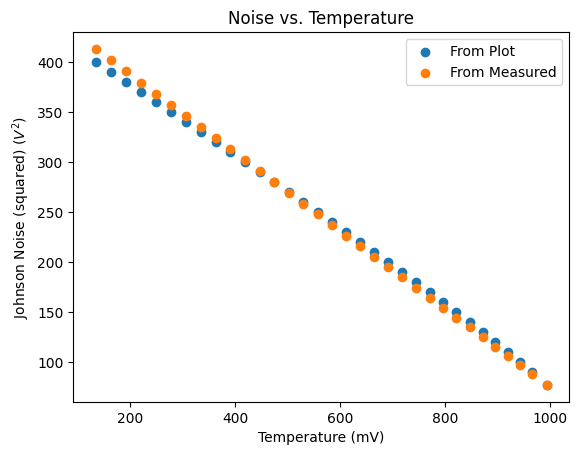

In [24]:
# Make a linear plot to compare the two linear fits
plt.scatter(mV_to_check, temps_to_check, label = "From Plot") # From plot
plt.scatter(np_mV_to_check, convert_mv_to_k_lab(np_mV_to_check), label = "From Measured") # From lab and fit
# plt.yrange(5,-5)
plt.xlabel(f'Temperature (mV)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Temperature')
plt.legend()
# plt.savefig('TimeDelay_vs_CableLength_ODRFit.png', dpi=300)
plt.show()

In [89]:
# Test function
temperature_k = []
for i in temperature[:-1]:
    temperature_k.append(convert_mv_to_k(eval(i)))

In [90]:
# <Vsq (t)> = {G1 G2}^2 / 10V <VJ^2 + VN^2>
# <VJ^2 + VN^2> = <Vsq (t)> * 10 V / {G1 G2}^2

def infer_noise(volts, G2, G1 = 600):
    return volts * 10 / ((G1 * G2)**2)

noise_tot = infer_noise(voltage, gain)
noise_tot_log = np.log10(noise_tot)

/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7756/2589727744.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


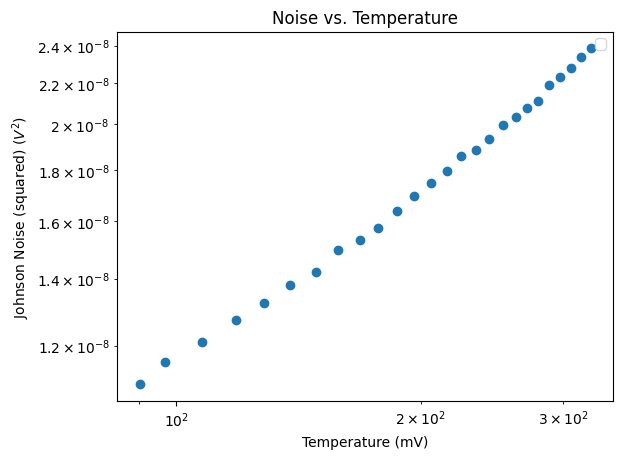

In [91]:
# Plot Data
plt.scatter(temperature_k[2:], noise_tot[2:-1])
plt.xscale('log')
plt.yscale('log')
# plt.yrange(5,-5)
plt.xlabel(f'Temperature (mV)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Temperature')
plt.legend()
# plt.savefig('TimeDelay_vs_CableLength_ODRFit.png', dpi=300)
plt.show()

In [92]:
min(noise_tot)
print(len(noise_tot))

29


29


/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7756/1030566055.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


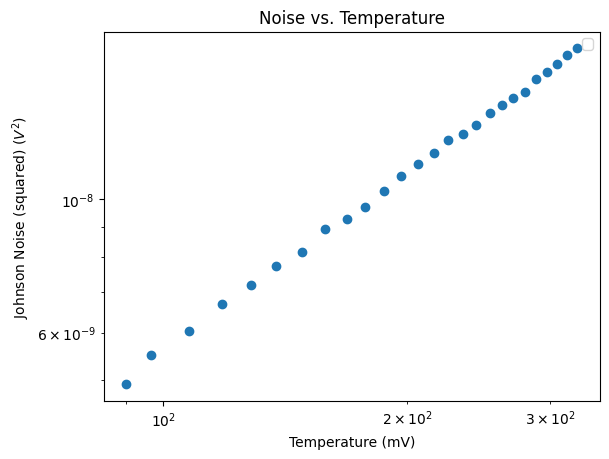

In [93]:
adjusted_noise = noise_tot - min(noise_tot)
print(len(adjusted_noise))
# Plot Data
plt.scatter(temperature_k[2:], adjusted_noise[2:-1])
plt.xscale('log')
plt.yscale('log')
# plt.yrange(5,-5)
plt.xlabel(f'Temperature (mV)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Temperature')
plt.legend()
# plt.savefig('TimeDelay_vs_CableLength_ODRFit.png', dpi=300)
plt.show()

In [94]:
# Fit to line
# Plot using ODR
def linear_func(B, x):
    return B[0] * x + B[1]
linear = odr.Model(linear_func)

mydata = odr.RealData(temperature_k[2:], adjusted_noise[2:-1])

sol = odr.ODR(mydata, linear, beta0=[9., 1.])
myoutput = sol.run()
myoutput.pprint()

Beta: [5.39969091e-11 2.37688581e-10]
Beta Std Error: [2.71681840e-13 5.99183918e-11]
Beta Covariance: [[ 7.70901449e-06 -1.61063902e-03]
 [-1.61063902e-03  3.74971222e-01]]
Residual Variance: 9.574637888166583e-21
Inverse Condition #: 0.001448037975386191
Reason(s) for Halting:
  Sum of squares convergence


In [95]:
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square

print("Chi squared: ", chi_sq)
print("Reduced Chi squared: ", red_chi_sq)

Chi squared:  2.2979130931599795e-19
Reduced Chi squared:  9.574637888166583e-21


<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7756/945378776.py:23: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2$: {chi_sq:.3f}\n"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7756/945378776.py:24: SyntaxWarning: invalid escape sequence '\c'
  f"Reduced $\chi^2$: {red_chi_sq:.3f}"


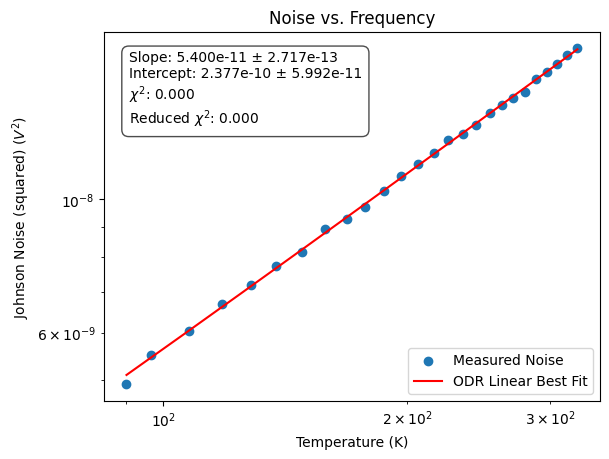

In [96]:
# Plot with best fit line
# Make a plot of time delay verus cable length

# Plot data
# plt.scatter(delta_f, noise_tot)
plt.scatter(temperature_k[2:], adjusted_noise[2:-1], label='Measured Noise')


# Plot best fit line
x_fit = np.linspace(min(temperature_k[2:]), max(temperature_k[2:]), 1000)
y_fit = linear_func(myoutput.beta, x_fit)
plt.plot(x_fit, y_fit, color='red', label='ODR Linear Best Fit')

slope = myoutput.beta[0]
slope_err = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_err = myoutput.sd_beta[1]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"Slope: {slope:.3e} ± {slope_err:.3e}\n"
    f"Intercept: {intercept:.3e} ± {intercept_err:.3e}\n"
    f"$\chi^2$: {chi_sq:.3f}\n"
    f"Reduced $\chi^2$: {red_chi_sq:.3f}"
)

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

plt.xlabel('Temperature (K)')
plt.xscale('log')
plt.yscale('log')
# plt.ylim(0,0.2E-10)
# plt.xlim(0,2E4)
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Frequency')
plt.legend()
plt.savefig('noise_vs_bandwidth_plot.png', dpi=300)
plt.show()

## Calculate Boltsmann Constant

Recall Johnson Noise Squared = 4 kb T R delta f

kb = Vj^2 / (4 * T * R * delta f); our slope is Vj^2 /delta_f, so multiply slope / (4 * T * R)

Recal Boltzmann constant is ~ 1.380649 × 10-23

In [99]:
R = 10000 # 100k Ohms
delta_f = 9997 # ~ 71 degrees F; Adjust in future
print("Slope: ", slope)
print("Calculated Boltzmann constant: ", slope / ((4 * delta_f * R)))

Slope:  5.3996909145909574e-11
Calculated Boltzmann constant:  1.350327826995838e-19


Don't forget to take into account capacitor affects.